In [2]:
import torch
import ot
from ot.backend import get_backend

In [7]:
import torch
import ot
from ot.backend import get_backend

# 배치 데이터 생성
batch_size = 32
n, m = 10, 8

# Source와 target distributions (batch)
a = torch.ones(batch_size, n) / n
b = torch.ones(batch_size, m) / m

# Cost matrices (batch)
xs = torch.randn(batch_size, n, 2)
xt = torch.randn(batch_size, m, 2)

# Structure matrices for Gromov-Wasserstein
C1 = torch.cdist(xs, xs)  # [batch, n, n]
C2 = torch.cdist(xt, xt)  # [batch, m, m]

# Feature cost for Fused GW
M = torch.cdist(xs, xt)   # [batch, n, m]

print("Testing batch Fused Gromov-Wasserstein...")

# Batch solve
from ot.batch import solve_gromov_batch

result = solve_gromov_batch(
    C1, C2,
    M=M,           # Feature cost (Fused)
    alpha=0.5,     # Balance between feature and structure
    reg=0.01,      # Entropic regularization
    a=a, b=b,
    max_iter=50
)

# OTResult 객체에서 transport plan 추출
T = result.value  # 또는 result.plan

print(f"✅ Success! Transport plan shape: {T.shape}")
print(f"Transport plan sum (should be ~1): {T[0].sum().item():.4f}")

# OTResult의 다른 속성들
print(f"\nOTResult attributes: {dir(result)}")

Testing batch Fused Gromov-Wasserstein...
✅ Success! Transport plan shape: torch.Size([32])
Transport plan sum (should be ~1): 0.5023

OTResult attributes: ['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_backend', '_batch_size', '_lazy_plan', '_log', '_plan', '_potentials', '_sparse_plan', '_status', '_value', '_value_linear', '_value_quad', 'a_to_b', 'b_to_a', 'citation', 'lazy_plan', 'log', 'marginal_a', 'marginal_b', 'marginals', 'plan', 'potential_a', 'potential_b', 'potentials', 'sparse_plan', 'status', 'value', 'value_linear', 'value_quad']


In [8]:
# result 객체 상세 확인
print("result type:", type(result))
print("result.plan:", result.plan)
print("result.plan shape:", result.plan.shape if hasattr(result.plan, 'shape') else 'No shape')

print("\nresult.value:", result.value)
print("result.value shape:", result.value.shape if hasattr(result.value, 'shape') else 'No shape')

print("\nresult._plan:", result._plan)
print("result._plan shape:", result._plan.shape if hasattr(result._plan, 'shape') else 'No shape')

# 실제 transport plan 찾기
for attr in ['plan', 'value', '_plan', 'lazy_plan']:
    try:
        val = getattr(result, attr)
        if hasattr(val, 'shape'):
            print(f"\n{attr}: shape = {val.shape}")
        elif callable(val):
            print(f"\n{attr}: callable")
        else:
            print(f"\n{attr}: {type(val)}")
    except:
        pass

result type: <class 'ot.utils.OTResult'>
result.plan: tensor([[[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          1.2500e-01, 0.0000e+00],
         [0.0000e+00, 6.1614e-02, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 1.2500e-01],
         ...,
         [6.3412e-02, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 1.2500e-01,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00]],

        [[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 6.2500e-02],
         [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 6.2500e-02],
         [0.0000e+00, 1.2500e-01, 0.0000e+00,  ..., 0.0000e+00,
          3.7008e-17, 0.0000e+00],
         ...,
         [1.2500e-01, 0.0

In [9]:
# Transport plan 추출
T = result.plan  # [batch_size, n, m]

print(f"✅ Success! Transport plan shape: {T.shape}")
print(f"Transport plan sum (should be ~1): {T[0].sum().item():.4f}")

# 각 batch의 OT cost
print(f"\nOT costs per batch: {result.value}")
print(f"Mean OT cost: {result.value.mean().item():.4f}")

✅ Success! Transport plan shape: torch.Size([32, 10, 8])
Transport plan sum (should be ~1): 1.0000

OT costs per batch: tensor([0.5023, 0.6622, 0.7131, 0.6981, 1.9785, 0.8327, 0.7183, 0.4698, 1.2592,
        1.1071, 0.5401, 1.1857, 0.9078, 0.7046, 0.4713, 0.7826, 0.7804, 0.6428,
        0.5671, 0.7145, 1.4467, 1.2298, 1.2340, 0.4336, 1.1677, 0.9825, 0.7323,
        0.6535, 0.9560, 0.7759, 0.9039, 0.8098])
Mean OT cost: 0.8614


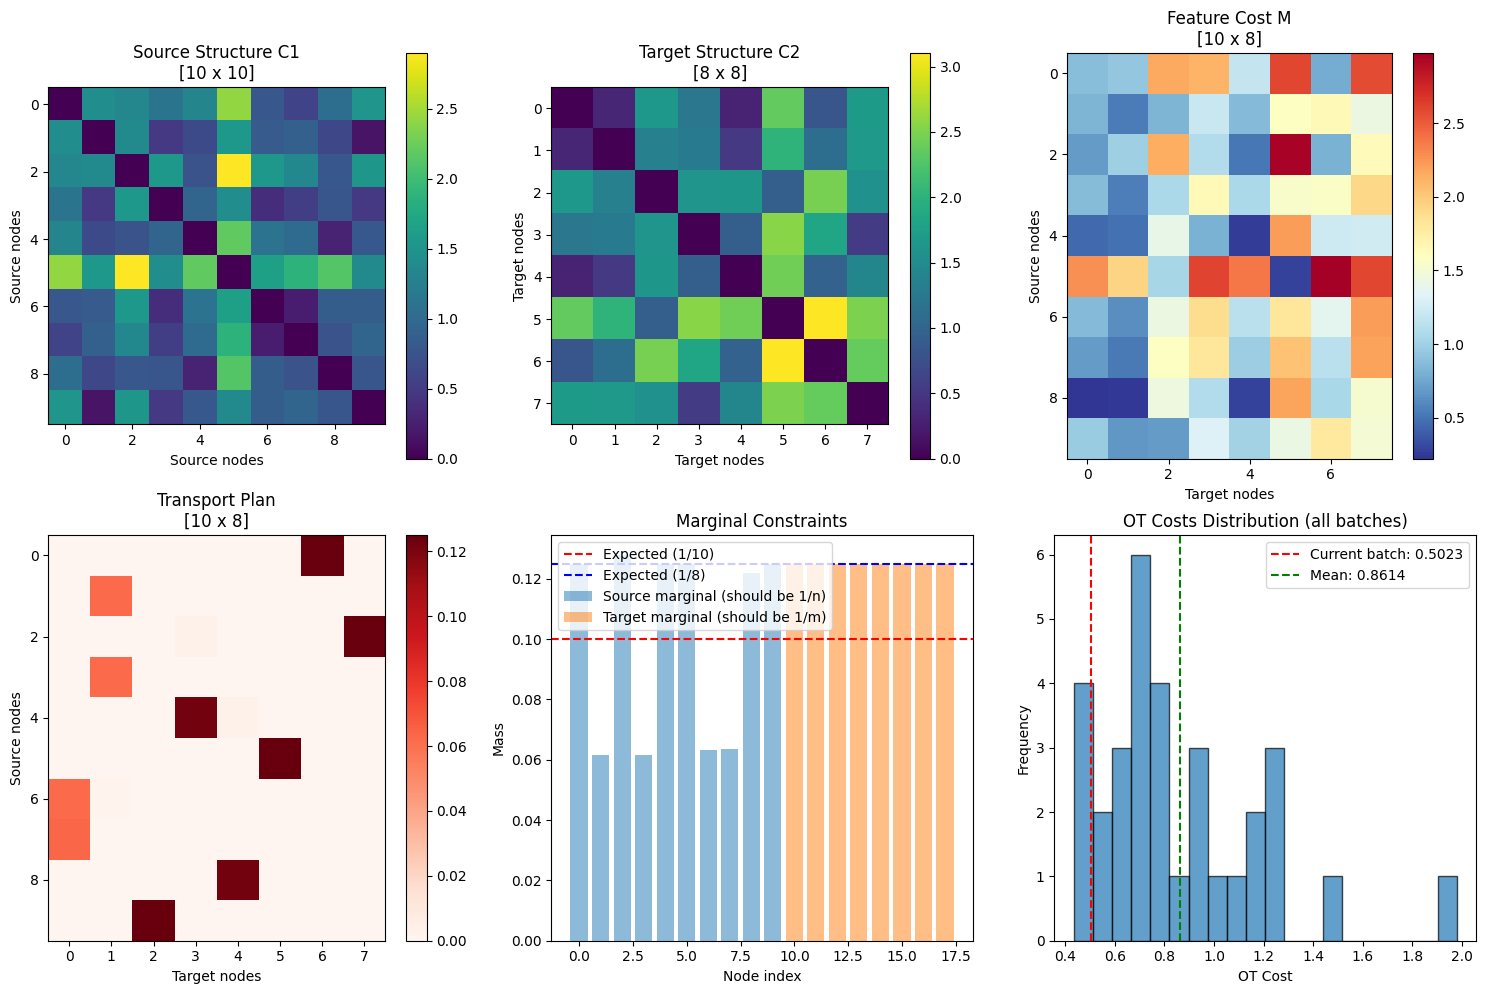


📊 Transport Plan Statistics (batch 0):
Min: 0.000000
Max: 0.125000
Mean: 0.012500
Sparsity: 83.8%

🔗 Top 5 strongest matchings:
  1. Source 2 → Target 7: 0.1250
  2. Source 9 → Target 2: 0.1250
  3. Source 5 → Target 5: 0.1250
  4. Source 0 → Target 6: 0.1250
  5. Source 8 → Target 4: 0.1220


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 첫 번째 batch 선택
idx = 0

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Source structure (C1)
ax = axes[0, 0]
im = ax.imshow(C1[idx].numpy(), cmap='viridis')
ax.set_title(f'Source Structure C1\n[{n} x {n}]')
ax.set_xlabel('Source nodes')
ax.set_ylabel('Source nodes')
plt.colorbar(im, ax=ax)

# 2. Target structure (C2)
ax = axes[0, 1]
im = ax.imshow(C2[idx].numpy(), cmap='viridis')
ax.set_title(f'Target Structure C2\n[{m} x {m}]')
ax.set_xlabel('Target nodes')
ax.set_ylabel('Target nodes')
plt.colorbar(im, ax=ax)

# 3. Feature cost (M)
ax = axes[0, 2]
im = ax.imshow(M[idx].numpy(), cmap='RdYlBu_r')
ax.set_title(f'Feature Cost M\n[{n} x {m}]')
ax.set_xlabel('Target nodes')
ax.set_ylabel('Source nodes')
plt.colorbar(im, ax=ax)

# 4. Transport Plan
ax = axes[1, 0]
T_vis = result.plan[idx].numpy()
im = ax.imshow(T_vis, cmap='Reds', aspect='auto')
ax.set_title(f'Transport Plan\n[{n} x {m}]')
ax.set_xlabel('Target nodes')
ax.set_ylabel('Source nodes')
plt.colorbar(im, ax=ax)

# 5. Marginals
ax = axes[1, 1]
marginal_source = T_vis.sum(axis=1)
marginal_target = T_vis.sum(axis=0)
ax.bar(range(n), marginal_source, alpha=0.5, label='Source marginal (should be 1/n)')
ax.axhline(1/n, color='r', linestyle='--', label=f'Expected (1/{n})')
ax.bar(range(n, n+m), marginal_target, alpha=0.5, label='Target marginal (should be 1/m)')
ax.axhline(1/m, color='b', linestyle='--', label=f'Expected (1/{m})')
ax.set_title('Marginal Constraints')
ax.set_xlabel('Node index')
ax.set_ylabel('Mass')
ax.legend()

# 6. OT costs distribution
ax = axes[1, 2]
ax.hist(result.value.numpy(), bins=20, edgecolor='black', alpha=0.7)
ax.axvline(result.value[idx].item(), color='r', linestyle='--', 
           label=f'Current batch: {result.value[idx].item():.4f}')
ax.axvline(result.value.mean().item(), color='g', linestyle='--',
           label=f'Mean: {result.value.mean().item():.4f}')
ax.set_title('OT Costs Distribution (all batches)')
ax.set_xlabel('OT Cost')
ax.set_ylabel('Frequency')
ax.legend()

plt.tight_layout()
plt.show()

# 추가: 매칭 강도 분석
print(f"\n📊 Transport Plan Statistics (batch {idx}):")
print(f"Min: {T_vis.min():.6f}")
print(f"Max: {T_vis.max():.6f}")
print(f"Mean: {T_vis.mean():.6f}")
print(f"Sparsity: {(T_vis < 1e-4).sum() / T_vis.size * 100:.1f}%")

# 가장 강한 매칭 찾기
top_k = 5
flat_idx = np.argsort(T_vis.flatten())[-top_k:][::-1]
print(f"\n🔗 Top {top_k} strongest matchings:")
for rank, flat_i in enumerate(flat_idx, 1):
    i, j = np.unravel_index(flat_i, T_vis.shape)
    print(f"  {rank}. Source {i} → Target {j}: {T_vis[i,j]:.4f}")

In [11]:
import torch
import ot
from ot.batch import solve_gromov_batch

# requires_grad=True로 설정
xs = torch.randn(4, 10, 2, requires_grad=True)
xt = torch.randn(4, 8, 2, requires_grad=True)

print(f"xs requires_grad: {xs.requires_grad}")

# Cost matrices
C1 = torch.cdist(xs, xs)
C2 = torch.cdist(xt, xt)
M = torch.cdist(xs, xt)

a = torch.ones(4, 10) / 10
b = torch.ones(4, 8) / 8

print(f"C1 requires_grad: {C1.requires_grad}")
print(f"M requires_grad: {M.requires_grad}")

# Solve
result = solve_gromov_batch(C1, C2, M=M, alpha=0.5, reg=0.01, a=a, b=b)

print(f"\nresult.value requires_grad: {result.value.requires_grad}")
print(f"result.plan requires_grad: {result.plan.requires_grad}")

# Backward 시도
try:
    loss = result.value.sum()
    loss.backward()
    print(f"\n✅ Backward successful!")
    print(f"xs.grad: {xs.grad is not None}")
    if xs.grad is not None:
        print(f"xs.grad norm: {xs.grad.norm().item():.6f}")
except Exception as e:
    print(f"\n❌ Backward failed: {e}")

xs requires_grad: True
C1 requires_grad: True
M requires_grad: True

result.value requires_grad: True
result.plan requires_grad: False

✅ Backward successful!
xs.grad: True
xs.grad norm: 0.644960
